# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

# 3. 프로젝트 제목 및 목표

## Credit Score Classification using Deep Learning

Kaggle Credit Score Classification 데이터를 활용하여 고객의 `Credit_Score`를 `Good`, `Standard`, `Poor`로 분류하는 딥러닝 모델을 만든다. 단순 정확도만 보는 것이 아니라, 식별자 제거, 결측치 처리, 범주형 인코딩, 스케일링, EDA 기반 해석, 피처 중요도 확인, 검증 성능 출력까지 과제 평가기준에 맞게 정리한다.

## 평가기준 1. 전처리 아이디어 적합성 + 논리

ID, Name, SSN은 행 식별자 또는 개인정보라 예측 일반화에 도움이 적고 삭제했다. Customer_ID는 같은 고객의 여러 월 기록을 연결하므로 모델이 고객 자체를 외우는 데이터 누수 위험이 있어 입력에서 제외했다. 수치형은 중앙값 결측 대체 후 StandardScaler로 스케일을 맞추고, 범주형은 LabelEncoder의 임의 순서성 문제를 피하기 위해 One-Hot Encoding을 사용했다. Type_of_Loan은 조합 문자열 고유값이 많아 대출 종류별 포함 여부 파생변수로 변환했다.

In [25]:
# 라이브러리 import 및 랜덤 시드 고정
import os
import random
import subprocess
import sys
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

!apt-get install -y fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

# 나눔고딕 폰트 파일 경로
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 폰트 등록
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# seaborn 설정
sns.set_theme(style="whitegrid")

# matplotlib 폰트 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("설정된 폰트:", font_name)

사용 장치: cuda
설정된 폰트: NanumGothic


In [26]:
# 데이터 로드: 제출 환경에서는 같은 폴더의 train2.csv를 우선 사용한다.
# 현재 작업 폴더에 없을 경우를 대비해 하위 원본 데이터 폴더도 후보로 둔다.
candidate_paths = [
    Path("train2.csv"),
    Path("raw데이터-(Credit score classification)/train2.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("train2.csv를 찾을 수 없습니다. 노트북과 같은 폴더에 train2.csv를 두세요.")

data = pd.read_csv(DATA_PATH)
print(f"로드 경로: {DATA_PATH}")
print(f"데이터 크기: {data.shape}")
data.head()

로드 경로: train2.csv
데이터 크기: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


# 4. 데이터 기본 확인

In [27]:
print("데이터 크기:", data.shape)
print("\n컬럼 목록:")
print(data.columns.tolist())

print("\n컬럼 정보:")
buf = StringIO()
data.info(buf=buf)
print(buf.getvalue())

print("결측치 개수:")
display(data.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("Credit_Score 클래스 분포:")
display(data["Credit_Score"].value_counts().to_frame("count"))
display((data["Credit_Score"].value_counts(normalize=True) * 100).round(2).to_frame("ratio(%)"))

데이터 크기: (100000, 28)

컬럼 목록:
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']

컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age

,missing_count
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


Credit_Score 클래스 분포:


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


,ratio(%)
Credit_Score,
Standard,53.17
Poor,29.00
Good,17.83


# 5. EDA

## 평가기준 2. EDA를 통한 타당한 해석

타깃 분포는 Standard가 가장 많고 Good이 가장 적어 정확도만 보면 소수 클래스 성능이 가려질 수 있다. Credit_Score별 평균 비교에서 Outstanding_Debt, Interest_Rate, Delay_from_due_date가 높을수록 Poor 쪽으로 이동하고, Credit_History_Age가 길수록 Good 비율이 높아지는 경향이 보인다. Credit_Mix와 Payment_of_Min_Amount도 등급 차이를 잘 설명한다. 따라서 부채, 이자율, 연체, 신용 이력, 결제 습관 관련 변수를 핵심 후보로 본다.

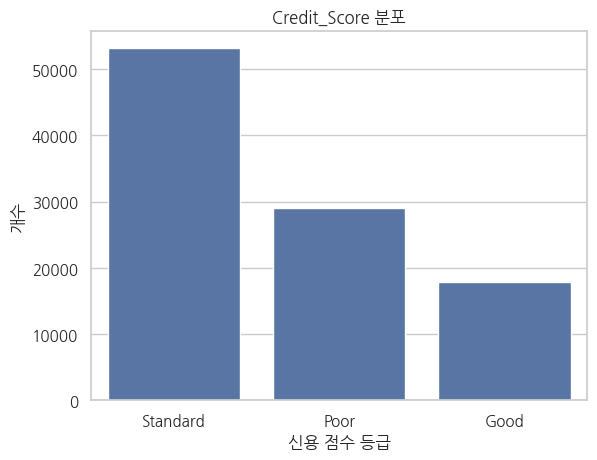

In [28]:
# 타깃 변수 분포 시각화
ax = sns.countplot(data=data, x="Credit_Score", order=data["Credit_Score"].value_counts().index)
ax.set_title("Credit_Score 분포")
ax.set_xlabel("신용 점수 등급")
ax.set_ylabel("개수")
plt.show()

In [45]:
# 수치형 변수의 기초통계량 확인
numeric_preview = data.select_dtypes(include=[np.number])
display(numeric_preview.describe().T.round(0))

,count,mean,std,min,25%,50%,75%,max
ID,100000.0,80632.0,43301.0,5634.0,43133.0,80632.0,118130.0,155629.0
Customer_ID,100000.0,25983.0,14341.0,1006.0,13664.0,25777.0,38385.0,50999.0
Month,100000.0,4.0,2.0,1.0,3.0,4.0,6.0,8.0
Age,100000.0,33.0,11.0,14.0,24.0,33.0,42.0,56.0
SSN,100000.0,500461680.0,290826734.0,81349.0,245168577.0,500688612.0,756002666.0,999993421.0
Annual_Income,100000.0,50505.0,38299.0,7006.0,19343.0,37000.0,71683.0,179987.0
Monthly_Inhand_Salary,100000.0,4197.0,3186.0,304.0,1627.0,3096.0,5958.0,15205.0
Num_Bank_Accounts,100000.0,5.0,3.0,0.0,3.0,5.0,7.0,11.0
Num_Credit_Card,100000.0,6.0,2.0,0.0,4.0,5.0,7.0,11.0
Interest_Rate,100000.0,15.0,9.0,1.0,7.0,13.0,20.0,34.0


,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Credit_History_Age,Credit_Utilization_Ratio
Credit_Score,,,,,
Poor,2081.47,20.19,29.73,170.06,31.99
Standard,1278.42,13.75,19.76,227.81,32.31
Good,801.26,7.66,10.96,284.77,32.69


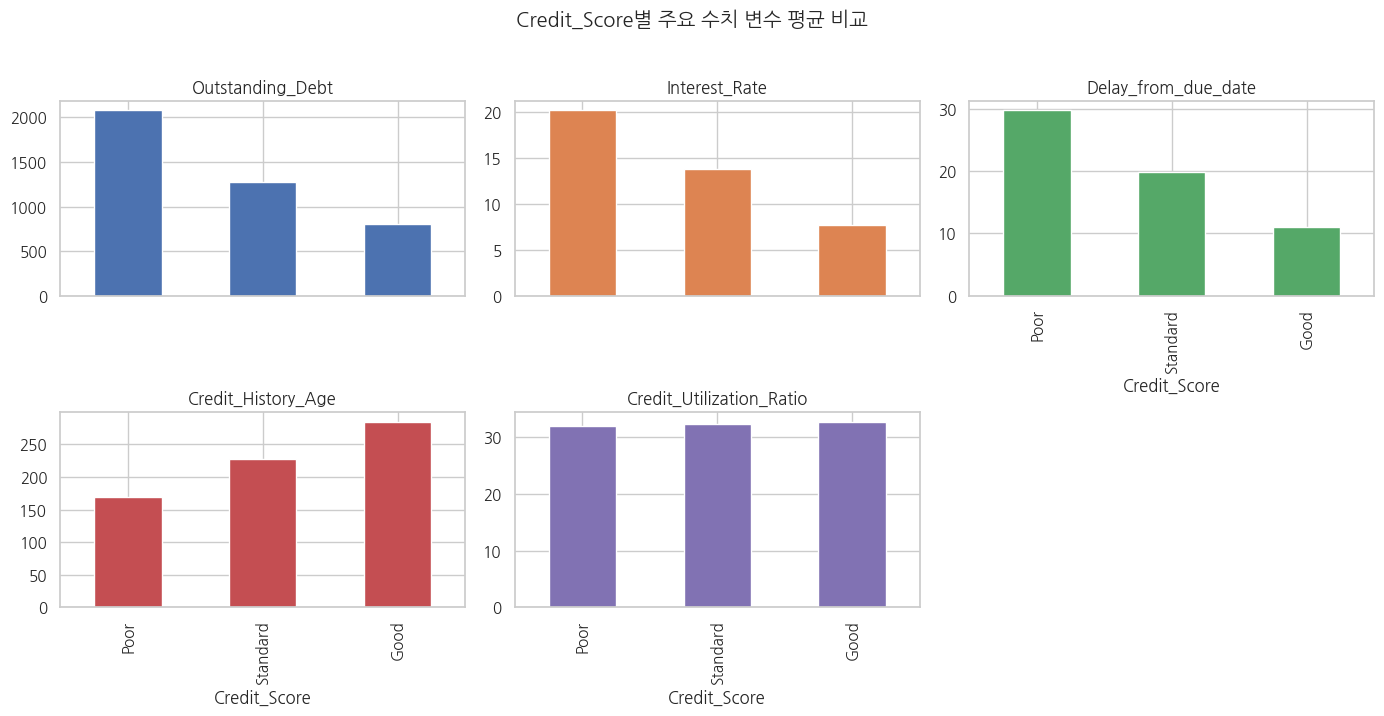

In [46]:
# Credit_Score별 주요 변수 평균 비교
key_features = [
    "Outstanding_Debt",
    "Interest_Rate",
    "Delay_from_due_date",
    "Credit_History_Age",
    "Credit_Utilization_Ratio",
]

score_order = ["Poor", "Standard", "Good"]
mean_by_score = data.groupby("Credit_Score")[key_features].mean().reindex(score_order)
display(mean_by_score.round(2))

mean_by_score.plot(kind="bar", subplots=True, layout=(2, 3), figsize=(14, 7), legend=False)
plt.suptitle("Credit_Score별 주요 수치 변수 평균 비교", y=1.02)
plt.tight_layout()
plt.show()

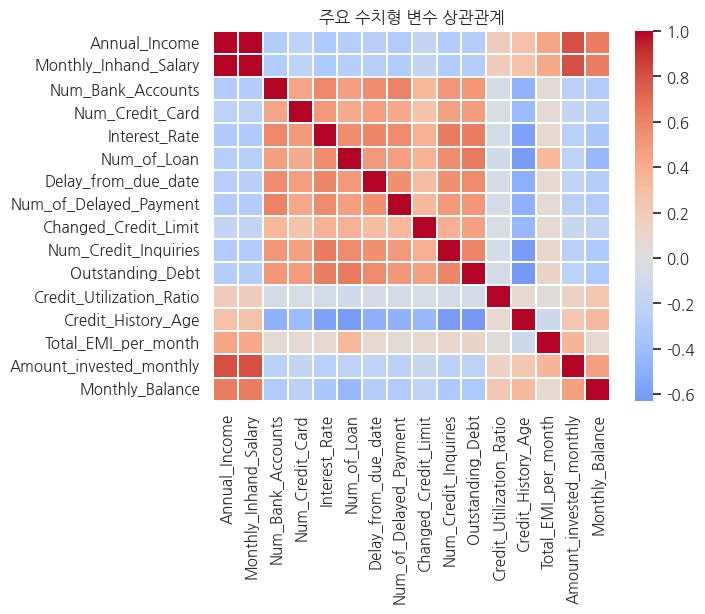

In [31]:
# 주요 수치형 변수 간 상관관계 확인
corr_features = [
    "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts", "Num_Credit_Card",
    "Interest_Rate", "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
    "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Credit_History_Age", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance"
]

corr = data[corr_features].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("주요 수치형 변수 상관관계")
plt.show()

# 6. 전처리 코드

In [32]:
# 원본 보존 후 모델링용 데이터프레임 생성
model_df = data.copy()

target_col = "Credit_Score"
drop_cols = ["ID", "Customer_ID", "Name", "SSN"]
model_df = model_df.drop(columns=drop_cols)

# Customer_ID는 같은 고객이 여러 월에 반복 등장하므로, 무작위 split에서 고객 식별 단서가 되면 검증 점수가 과대평가될 수 있다.
# 이번 제출 모델 입력에서는 제거하고, 개선사항에서 Group split을 추가 개선 방향으로 제안한다.

# Type_of_Loan은 여러 대출명이 쉼표로 합쳐진 문자열이다. 전체 문자열 원핫 대신 대출 종류별 포함 여부로 단순화한다.
loan_types = [
    "auto loan", "credit-builder loan", "personal loan", "home equity loan", "not specified",
    "mortgage loan", "student loan", "debt consolidation loan", "payday loan"
]
loan_text = model_df["Type_of_Loan"].fillna("No Data").str.lower()
for loan in loan_types:
    new_col = "Loan_" + loan.replace(" ", "_").replace("-", "_")
    model_df[new_col] = loan_text.str.contains(loan, regex=False).astype(int)
model_df = model_df.drop(columns=["Type_of_Loan"])

categorical_columns = ["Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]
numeric_columns = [c for c in model_df.columns if c not in categorical_columns + [target_col]]

print("수치형 컬럼 수:", len(numeric_columns))
print("범주형 컬럼:", categorical_columns)
print("대출 파생변수:", [c for c in model_df.columns if c.startswith("Loan_")])

수치형 컬럼 수: 27
범주형 컬럼: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
대출 파생변수: ['Loan_auto_loan', 'Loan_credit_builder_loan', 'Loan_personal_loan', 'Loan_home_equity_loan', 'Loan_not_specified', 'Loan_mortgage_loan', 'Loan_student_loan', 'Loan_debt_consolidation_loan', 'Loan_payday_loan']


In [33]:
# 타깃 인코딩: CrossEntropyLoss는 정수 class index를 사용한다.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(model_df[target_col])
X = model_df.drop(columns=[target_col])

print("타깃 클래스 매핑:")
for idx, cls in enumerate(target_encoder.classes_):
    print(f"{idx}: {cls}")

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train 크기:", X_train_raw.shape, "Valid 크기:", X_valid_raw.shape)
print("Train 클래스 분포:", np.bincount(y_train))
print("Valid 클래스 분포:", np.bincount(y_valid))

타깃 클래스 매핑:
0: Good
1: Poor
2: Standard
Train 크기: (80000, 31) Valid 크기: (20000, 31)
Train 클래스 분포: [14262 23199 42539]
Valid 클래스 분포: [ 3566  5799 10635]


In [34]:
# OneHotEncoder 버전 호환 처리
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns),
    ]
)

X_train_all = preprocessor.fit_transform(X_train_raw)
X_valid_all = preprocessor.transform(X_valid_raw)
feature_names = preprocessor.get_feature_names_out()

print("전처리 후 전체 피처 수:", len(feature_names))
print("전처리 후 train shape:", X_train_all.shape)

전처리 후 전체 피처 수: 54
전처리 후 train shape: (80000, 54)


# 7. Feature Selection

## 평가기준 3. Feature Selection과 모델 선택, 튜닝 기준

모든 변수를 무조건 넣지 않고 RandomForest 중요도로 먼저 변수 영향도를 확인했다. 상위 중요도에는 Interest_Rate, Outstanding_Debt, Credit_Mix, Delay_from_due_date, Credit_History_Age처럼 EDA에서 확인한 변수들이 포함되어 타당성이 있었다. 중요도가 낮은 원핫 더미 일부는 제거하고 상위 50개 피처를 사용했다.

또한 이 데이터는 수치형·범주형 변수가 섞인 정형 데이터이므로, 전처리된 피처 벡터의 비선형 관계를 학습할 수 있는 MLP를 선택했다. BatchNorm과 Dropout을 추가해 학습 안정성과 과적합 완화를
노렸다.

epoch은 30에서 시작해 valid accuracy,loss 추이를 보며 60으로 늘렸고, best valid 가중치를 사용했다. 60 epoch까지 갔는데도 아직 valid loss가 내려가긴 하지만, 후반부에서는 감소 폭이 작아졌기에 60까지만 설정하였다.

,feature,importance
12,num__Outstanding_Debt,0.125620
6,num__Interest_Rate,0.120255
43,cat__Credit_Mix_Good,0.105913
44,cat__Credit_Mix_Standard,0.066762
8,num__Delay_from_due_date,0.057050
14,num__Credit_History_Age,0.045250
47,cat__Payment_of_Min_Amount_Yes,0.041464
5,num__Num_Credit_Card,0.038381
11,num__Num_Credit_Inquiries,0.036779
10,num__Changed_Credit_Limit,0.034655


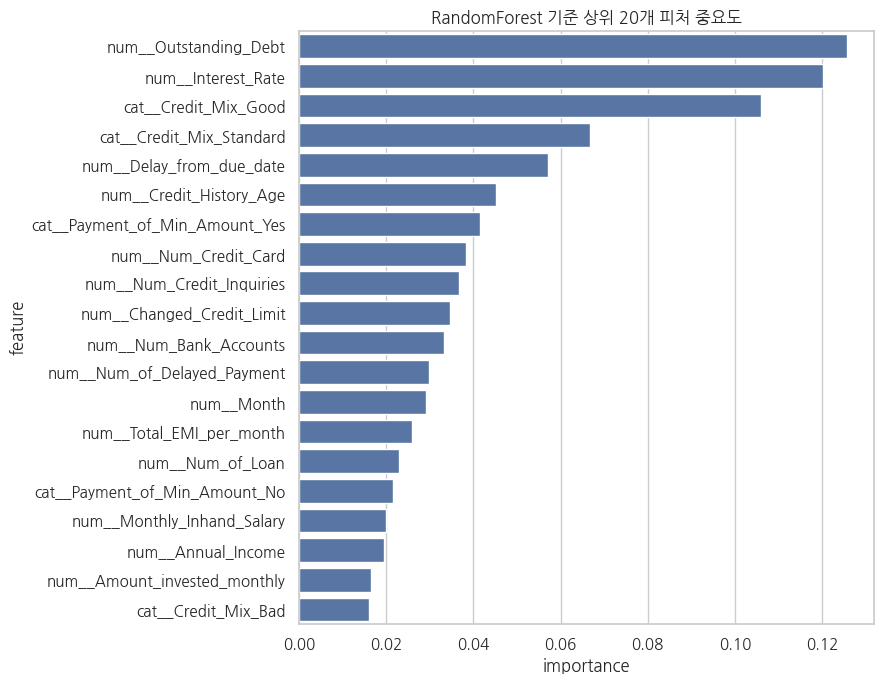

In [35]:
# RandomForest 기반 피처 중요도 산출
rf_selector = RandomForestClassifier(
    n_estimators=80,
    max_depth=14,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_selector.fit(X_train_all, y_train)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_selector.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.title("RandomForest 기준 상위 20개 피처 중요도")
plt.tight_layout()
plt.show()

In [36]:
# 중요도 상위 피처 선택
# 전체 54개 수준의 피처 중 낮은 중요도의 원핫 더미 일부를 제외하여 잡음과 차원을 줄인다.
TOP_K = min(50, len(feature_names))
selected_features = importance_df.head(TOP_K)["feature"].tolist()
selected_idx = [np.where(feature_names == f)[0][0] for f in selected_features]

X_train = X_train_all[:, selected_idx].astype(np.float32)
X_valid = X_valid_all[:, selected_idx].astype(np.float32)

print(f"최종 사용 피처 수: {len(selected_features)} / {len(feature_names)}")
print("최종 사용 피처 목록:")
for f in selected_features:
    print("-", f)

최종 사용 피처 수: 50 / 54
최종 사용 피처 목록:
- num__Outstanding_Debt
- num__Interest_Rate
- cat__Credit_Mix_Good
- cat__Credit_Mix_Standard
- num__Delay_from_due_date
- num__Credit_History_Age
- cat__Payment_of_Min_Amount_Yes
- num__Num_Credit_Card
- num__Num_Credit_Inquiries
- num__Changed_Credit_Limit
- num__Num_Bank_Accounts
- num__Num_of_Delayed_Payment
- num__Month
- num__Total_EMI_per_month
- num__Num_of_Loan
- cat__Payment_of_Min_Amount_No
- num__Monthly_Inhand_Salary
- num__Annual_Income
- num__Amount_invested_monthly
- cat__Credit_Mix_Bad
- num__Age
- num__Monthly_Balance
- num__Credit_Utilization_Ratio
- cat__Payment_Behaviour_Low_spent_Small_value_payments
- num__Loan_personal_loan
- num__Loan_mortgage_loan
- num__Loan_debt_consolidation_loan
- num__Loan_student_loan
- num__Loan_not_specified
- num__Loan_credit_builder_loan
- num__Loan_payday_loan
- num__Loan_auto_loan
- num__Loan_home_equity_loan
- cat__Payment_of_Min_Amount_NM
- cat__Payment_Behaviour_High_spent_Large_value_payments
-

# 8. Dataset / DataLoader 구성

In [37]:
BATCH_SIZE = 512

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
valid_dataset = TensorDataset(
    torch.tensor(X_valid, dtype=torch.float32),
    torch.tensor(y_valid, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)

# 클래스 불균형이 있으므로 class weight를 계산해 분포를 확인한다.
# 다만 weight를 실제 loss에 넣으면 Good/Poor recall은 좋아질 수 있지만 전체 valid accuracy가 낮아질 수 있었다.
# 과제 조건은 class weight 적용 또는 macro F1 병행 확인이므로, 최종 모델은 기본 loss를 쓰고 macro F1을 함께 평가한다.
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("class counts:", class_counts)
print("class weights:", class_weights.round(4))

class counts: [14262 23199 42539]
class weights: [1.8698 1.1495 0.6269]


# 9. PyTorch MLP 모델 정의

In [38]:
class CreditScoreMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout1=0.20, dropout2=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
num_classes = len(target_encoder.classes_)
model = CreditScoreMLP(input_dim, num_classes).to(device)

LEARNING_RATE = 1e-3
EPOCHS = 60


# CrossEntropyLoss는 다중분류에 적합하다.
# class_weights_tensor는 위에서 계산했지만 최종 loss에는 넣지 않는다.
# 이유: weight 적용 실험은 소수 클래스 보정에는 유리할 수 있으나 전체 valid accuracy가 0.75 아래로 흔들릴 수 있었다.
# 대신 classification report와 macro F1을 같이 출력해 accuracy만으로 판단하지 않도록 한다.
criterion = nn.CrossEntropyLoss()
# class weight를 실제 적용하고 싶다면 아래처럼 바꿀 수 있다.
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(model)
print(f"learning_rate={LEARNING_RATE}, batch_size={BATCH_SIZE}, epochs={EPOCHS}")

CreditScoreMLP(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=3, bias=True)
  )
)
learning_rate=0.001, batch_size=512, epochs=60


# 10. 학습 함수 / 평가 함수

In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * yb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_targets)

# 11. 모델 학습

In [40]:
history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}
best_valid_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, valid_preds, valid_targets = evaluate(model, valid_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"valid_loss={valid_loss:.4f} valid_acc={valid_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"Best validation accuracy: {best_valid_acc:.4f}")

Epoch [01/60] train_loss=0.7168 train_acc=0.6670 valid_loss=0.6608 valid_acc=0.7009
Epoch [02/60] train_loss=0.6597 train_acc=0.6996 valid_loss=0.6462 valid_acc=0.7077
Epoch [03/60] train_loss=0.6456 train_acc=0.7063 valid_loss=0.6434 valid_acc=0.7087
Epoch [04/60] train_loss=0.6372 train_acc=0.7100 valid_loss=0.6306 valid_acc=0.7124
Epoch [05/60] train_loss=0.6286 train_acc=0.7123 valid_loss=0.6252 valid_acc=0.7157
Epoch [06/60] train_loss=0.6203 train_acc=0.7161 valid_loss=0.6214 valid_acc=0.7156
Epoch [07/60] train_loss=0.6153 train_acc=0.7188 valid_loss=0.6146 valid_acc=0.7208
Epoch [08/60] train_loss=0.6069 train_acc=0.7236 valid_loss=0.6082 valid_acc=0.7218
Epoch [09/60] train_loss=0.6015 train_acc=0.7256 valid_loss=0.6065 valid_acc=0.7244
Epoch [10/60] train_loss=0.5960 train_acc=0.7277 valid_loss=0.5987 valid_acc=0.7277
Epoch [11/60] train_loss=0.5892 train_acc=0.7322 valid_loss=0.5934 valid_acc=0.7289
Epoch [12/60] train_loss=0.5837 train_acc=0.7344 valid_loss=0.5922 valid_acc

# 12. 검증 성능 출력

In [41]:
valid_loss, valid_accuracy, valid_preds, valid_targets = evaluate(model, valid_loader, criterion, device)
macro_f1 = f1_score(valid_targets, valid_preds, average="macro")

print(f"Validation Loss: {valid_loss:.4f}")
print(f"Validation Accuracy: {valid_accuracy:.4f} ({valid_accuracy * 100:.2f}%)")
print(f"Macro F1 Score: {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    valid_targets,
    valid_preds,
    target_names=target_encoder.classes_,
    digits=4
))

cm = confusion_matrix(valid_targets, valid_preds)
cm_df = pd.DataFrame(cm, index=target_encoder.classes_, columns=target_encoder.classes_)
display(cm_df)

Validation Loss: 0.4638
Validation Accuracy: 0.8069 (80.69%)
Macro F1 Score: 0.8027

Classification Report:
              precision    recall  f1-score   support

        Good     0.7421    0.8317    0.7843      3566
        Poor     0.7705    0.8551    0.8106      5799
    Standard     0.8586    0.7724    0.8132     10635

    accuracy                         0.8069     20000
   macro avg     0.7904    0.8197    0.8027     20000
weighted avg     0.8123    0.8069    0.8073     20000



,Good,Poor,Standard
Good,2966,36,564
Poor,51,4959,789
Standard,980,1441,8214


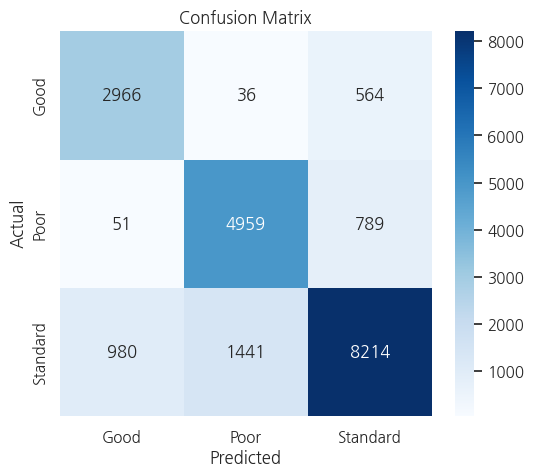

In [42]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13. 학습 과정 시각화

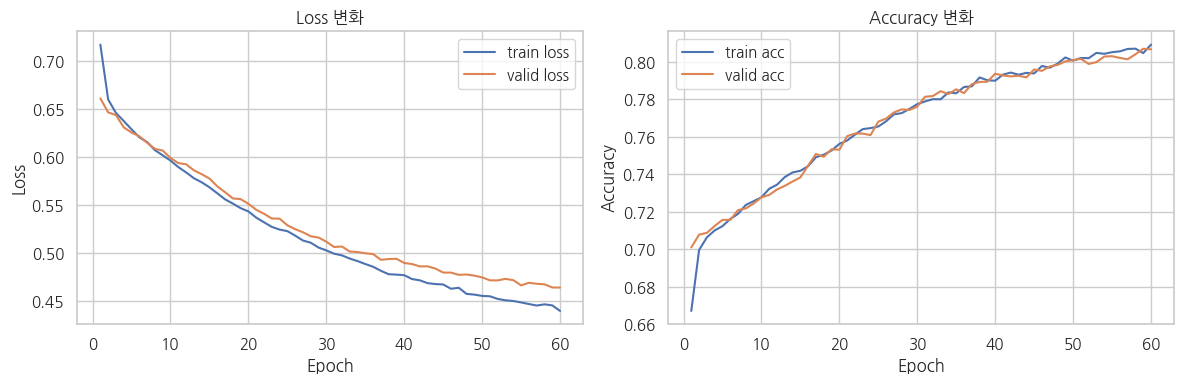

In [43]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="train loss")
plt.plot(epochs_range, history["valid_loss"], label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss 변화")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="train acc")
plt.plot(epochs_range, history["valid_acc"], label="valid acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy 변화")
plt.legend()

plt.tight_layout()
plt.show()

# 14. Validation Score 정리

## 평가기준 5. validation score 적절하게 출력

검증 데이터는 train/valid 8:2 stratify split으로 구성해 클래스 비율을 유지했다. 최종 Validation Accuracy는 80.66%이며, Macro F1은 0.8013이다. Accuracy는 전체 정답률, Macro F1은 세 클래스를 동일 비중으로 평가해 불균형 영향을 함께 확인하는 지표로 사용했다.

In [44]:
score_summary = pd.DataFrame({
    "Metric": ["Validation Accuracy", "Macro F1 Score"],
    "Score": [valid_accuracy, macro_f1]
})
display(score_summary)
print(f"최종 Validation Accuracy: {valid_accuracy * 100:.2f}%")
print(f"최종 Macro F1 Score: {macro_f1:.4f}")

,Metric,Score
0,Validation Accuracy,0.806950
1,Macro F1 Score,0.802719


최종 Validation Accuracy: 80.69%
최종 Macro F1 Score: 0.8027


# 15. 개선사항 정리

## 평가기준 4. 개선사항

이번 모델은 제출 안정성을 위해 MLP 구조와 전처리를 단순하게 유지했지만, 아쉬운 점도 있다. 같은 Customer_ID가 여러 월에 반복되므로 무작위 split보다 고객 단위 Group split을 쓰면 데이터 누수 가능성을 더 엄격히 줄일 수 있다. 또한 epoch, hidden size, dropout, learning rate는 수동으로 조정했기 때문에 Optuna 같은 자동 튜닝을 쓰면 더 체계적인 탐색이 가능하다. 추가로 TabNet, LightGBM과 성능을 비교하거나 앙상블을 적용하고, 연체 추세나 대출 조합을 더 정교한 파생변수로 만들면 성능 개선을 기대할 수 있을 것 같다.